In [1]:
import os
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

print("TabTransformer environment ready!")

TabTransformer environment ready!


In [22]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
import os

BASE = "/content/drive/MyDrive/DL-Assignment"

print("DL-Assignment exists:", os.path.exists(BASE))

if os.path.exists(BASE):
    print("\nContents:")
    print(os.listdir(BASE))

PROCESSED_V2 = os.path.join(BASE, "data", "processed_v2")

print("\nprocessed_v2 exists:", os.path.exists(PROCESSED_V2))

if os.path.exists(PROCESSED_V2):
    print("\nV2 files:")
    print(os.listdir(PROCESSED_V2))

DL-Assignment exists: True

Contents:
['data']

processed_v2 exists: True

V2 files:
['X_train.npy', 'y_train.npy', 'X_val.npy', 'y_val.npy', 'X_test.npy', 'y_test.npy', 'class_weights.npy', 'class_counts.npy', 'scaler.pkl', 'feature_names.txt']


In [2]:
!git clone -b ushara-eda https://github.com/Jana1805/DL-Assignment.git

Cloning into 'DL-Assignment'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 41 (delta 14), reused 33 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 12.64 MiB | 6.27 MiB/s, done.
Resolving deltas: 100% (14/14), done.
Updating files: 100% (15/15), done.


In [3]:
import os

print("Repository exists:", os.path.exists("/content/DL-Assignment"))

print("\nDataset files:")
print(os.listdir("/content/DL-Assignment/dataset"))

Repository exists: True

Dataset files:
['apachejit_test_small.csv', 'apachejit_total.csv', 'apachejit_test_large.csv', 'apachejit_train.csv', 'apachejit_total_with_messages.csv']


In [4]:
DATA_PATH = "/content/DL-Assignment/dataset/apachejit_total.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Year range:", df["year"].min(), "-", df["year"].max())

Dataset loaded successfully!
Shape: (106674, 18)
Year range: 2003 - 2019


In [24]:
import os
import numpy as np

DATA_DIR_V2 = "/content/drive/MyDrive/DL-Assignment/data/processed_v2"

X_train_v2 = np.load(os.path.join(DATA_DIR_V2, "X_train.npy"))
y_train_v2 = np.load(os.path.join(DATA_DIR_V2, "y_train.npy"))

X_val_v2 = np.load(os.path.join(DATA_DIR_V2, "X_val.npy"))
y_val_v2 = np.load(os.path.join(DATA_DIR_V2, "y_val.npy"))

X_test_v2 = np.load(os.path.join(DATA_DIR_V2, "X_test.npy"))
y_test_v2 = np.load(os.path.join(DATA_DIR_V2, "y_test.npy"))

class_weights_v2 = np.load(
    os.path.join(DATA_DIR_V2, "class_weights.npy")
)

INPUT_DIM_V2 = X_train_v2.shape[1]

print("V2 data loaded successfully!")

print("X_train_v2:", X_train_v2.shape)
print("X_val_v2  :", X_val_v2.shape)
print("X_test_v2 :", X_test_v2.shape)
print("Input dimension:", INPUT_DIM_V2)

print("\nClass weights:")
print(class_weights_v2)

V2 data loaded successfully!
X_train_v2: (52133, 17)
X_val_v2  : (24430, 17)
X_test_v2 : (30111, 17)
Input dimension: 17

Class weights:
[0.7051289  1.71874588]


In [5]:
DATA_PATH = "/content/DL-Assignment/dataset/apachejit_total.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Year range:", df["year"].min(), "-", df["year"].max())

Dataset loaded successfully!
Shape: (106674, 18)
Year range: 2003 - 2019


In [7]:
RAW_FEATURE_COLUMNS = [
    "la", "ld", "nf", "nd", "ns", "ent",
    "ndev", "age", "nuc", "aexp", "arexp", "asexp"
]

ALL_FEATURE_COLUMNS = RAW_FEATURE_COLUMNS

LABEL_COLUMN = "buggy"

print("TabTransformer V1")
print("Number of features:", len(ALL_FEATURE_COLUMNS))

print("\nFeatures:")
print(ALL_FEATURE_COLUMNS)

print("\nTarget:", LABEL_COLUMN)

TabTransformer V1
Number of features: 12

Features:
['la', 'ld', 'nf', 'nd', 'ns', 'ent', 'ndev', 'age', 'nuc', 'aexp', 'arexp', 'asexp']

Target: buggy


In [8]:
TRAIN_YEAR_MAX = 2014
VAL_YEAR_MIN = 2015
VAL_YEAR_MAX = 2016
TEST_YEAR_MIN = 2017

train_df = df[
    df["year"] <= TRAIN_YEAR_MAX
].reset_index(drop=True)

val_df = df[
    (df["year"] >= VAL_YEAR_MIN) &
    (df["year"] <= VAL_YEAR_MAX)
].reset_index(drop=True)

test_df = df[
    df["year"] >= TEST_YEAR_MIN
].reset_index(drop=True)

print("TabTransformer V1 chronological split completed!\n")

print(f"Train      : {len(train_df)} rows | 2003-2014")
print(f"Validation : {len(val_df)} rows | 2015-2016")
print(f"Test       : {len(test_df)} rows | 2017-2019")

TabTransformer V1 chronological split completed!

Train      : 52133 rows | 2003-2014
Validation : 24430 rows | 2015-2016
Test       : 30111 rows | 2017-2019


In [9]:
X_train = train_df[ALL_FEATURE_COLUMNS].values.astype(np.float32)
y_train = train_df[LABEL_COLUMN].values.astype(np.int64)

X_val = val_df[ALL_FEATURE_COLUMNS].values.astype(np.float32)
y_val = val_df[LABEL_COLUMN].values.astype(np.int64)

X_test = test_df[ALL_FEATURE_COLUMNS].values.astype(np.float32)
y_test = test_df[LABEL_COLUMN].values.astype(np.int64)

print("TabTransformer V1 feature and label extraction completed!\n")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nNumber of features:", X_train.shape[1])

TabTransformer V1 feature and label extraction completed!

X_train: (52133, 12)
y_train: (52133,)
X_val: (24430, 12)
y_val: (24430,)
X_test: (30111, 12)
y_test: (30111,)

Number of features: 12


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on V1 training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to validation and test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("TabTransformer V1 scaling completed!")

print("\nShapes:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

print("\nTraining mean:")
print(np.round(X_train_scaled.mean(axis=0), 3))

print("\nTraining standard deviation:")
print(np.round(X_train_scaled.std(axis=0), 3))

TabTransformer V1 scaling completed!

Shapes:
X_train_scaled: (52133, 12)
X_val_scaled: (24430, 12)
X_test_scaled: (30111, 12)

Training mean:
[-0.  0. -0.  0. -0.  0.  0. -0. -0.  0.  0.  0.]

Training standard deviation:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [11]:
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader

# Calculate class weights using V1 training data only
classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

print("V1 Class weights:")
print("Clean (0):", class_weights[0])
print("Buggy (1):", class_weights[1])

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

# Create datasets
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

# Create DataLoaders
BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nV1 DataLoaders created successfully!")
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

V1 Class weights:
Clean (0): 0.7051288987475316
Buggy (1): 1.7187458789397336

V1 DataLoaders created successfully!
Training batches: 204
Validation batches: 96
Test batches: 118


In [25]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert V2 data to PyTorch tensors
X_train_tensor_v2 = torch.tensor(
    X_train_v2,
    dtype=torch.float32
)

y_train_tensor_v2 = torch.tensor(
    y_train_v2,
    dtype=torch.long
)

X_val_tensor_v2 = torch.tensor(
    X_val_v2,
    dtype=torch.float32
)

y_val_tensor_v2 = torch.tensor(
    y_val_v2,
    dtype=torch.long
)

X_test_tensor_v2 = torch.tensor(
    X_test_v2,
    dtype=torch.float32
)

y_test_tensor_v2 = torch.tensor(
    y_test_v2,
    dtype=torch.long
)


# Create TensorDatasets
train_dataset_v2 = TensorDataset(
    X_train_tensor_v2,
    y_train_tensor_v2
)

val_dataset_v2 = TensorDataset(
    X_val_tensor_v2,
    y_val_tensor_v2
)

test_dataset_v2 = TensorDataset(
    X_test_tensor_v2,
    y_test_tensor_v2
)


# Batch size
BATCH_SIZE_V2 = 256


# Create DataLoaders
train_loader_v2 = DataLoader(
    train_dataset_v2,
    batch_size=BATCH_SIZE_V2,
    shuffle=True
)

val_loader_v2 = DataLoader(
    val_dataset_v2,
    batch_size=BATCH_SIZE_V2,
    shuffle=False
)

test_loader_v2 = DataLoader(
    test_dataset_v2,
    batch_size=BATCH_SIZE_V2,
    shuffle=False
)


print("V2 PyTorch DataLoaders created successfully!")

print("Training batches:", len(train_loader_v2))
print("Validation batches:", len(val_loader_v2))
print("Test batches:", len(test_loader_v2))

V2 PyTorch DataLoaders created successfully!
Training batches: 204
Validation batches: 96
Test batches: 118


In [12]:
class TabTransformerV1(nn.Module):
    def __init__(
        self,
        input_dim,
        embedding_dim=32,
        num_heads=4,
        num_layers=2,
        dropout=0.3
    ):
        super().__init__()

        # Convert each numerical feature into an embedding
        self.feature_embeddings = nn.Linear(1, embedding_dim)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=64,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_dim * embedding_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        # [batch, features]
        x = x.unsqueeze(-1)

        # [batch, features, 1]
        x = self.feature_embeddings(x)

        # [batch, features, embedding_dim]
        x = self.transformer(x)

        # Classification
        output = self.classifier(x)

        return output


# V1 = 12 features
INPUT_DIM_V1 = X_train_scaled.shape[1]

model_v1 = TabTransformerV1(
    input_dim=INPUT_DIM_V1,
    embedding_dim=32,
    num_heads=4,
    num_layers=2,
    dropout=0.3
)

print(model_v1)

total_params_v1 = sum(
    p.numel() for p in model_v1.parameters()
)

trainable_params_v1 = sum(
    p.numel()
    for p in model_v1.parameters()
    if p.requires_grad
)

print("\nV1 Input features:", INPUT_DIM_V1)
print("Total parameters:", total_params_v1)
print("Trainable parameters:", trainable_params_v1)

TabTransformerV1(
  (feature_embeddings): Linear(in_features=1, out_features=32, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=384, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_f

In [26]:
class TabTransformerV2(nn.Module):
    def __init__(
        self,
        input_dim,
        embedding_dim=32,
        num_heads=4,
        num_layers=2,
        dropout=0.3
    ):
        super().__init__()

        # Convert each numerical feature into an embedding
        self.feature_embeddings = nn.Linear(
            1,
            embedding_dim
        )

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=64,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(
                input_dim * embedding_dim,
                128
            ),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 2)
        )

    def forward(self, x):

        # [batch, features]
        x = x.unsqueeze(-1)

        # [batch, features, 1]
        x = self.feature_embeddings(x)

        # [batch, features, embedding_dim]
        x = self.transformer(x)

        # Classification
        output = self.classifier(x)

        return output


# V2 = 17 features
INPUT_DIM_V2 = X_train_v2.shape[1]

model_v2 = TabTransformerV2(
    input_dim=INPUT_DIM_V2,
    embedding_dim=32,
    num_heads=4,
    num_layers=2,
    dropout=0.3
)

print(model_v2)

total_params_v2 = sum(
    p.numel()
    for p in model_v2.parameters()
)

trainable_params_v2 = sum(
    p.numel()
    for p in model_v2.parameters()
    if p.requires_grad
)

print("\nV2 Input features:", INPUT_DIM_V2)
print("Total parameters:", total_params_v2)
print("Trainable parameters:", trainable_params_v2)

TabTransformerV2(
  (feature_embeddings): Linear(in_features=1, out_features=32, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=544, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_f

In [13]:
# Select device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Move V1 model to device
model_v1 = model_v1.to(device)

# Convert V1 class weights to tensor
class_weights_tensor_v1 = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

# Weighted Cross-Entropy Loss
criterion_v1 = nn.CrossEntropyLoss(
    weight=class_weights_tensor_v1
)

# Adam optimizer
optimizer_v1 = optim.Adam(
    model_v1.parameters(),
    lr=1e-3
)

# Learning-rate scheduler
scheduler_v1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v1,
    mode="min",
    factor=0.5,
    patience=5
)

print("TabTransformer V1 setup completed!")
print("Device:", device)
print("Loss function: Weighted CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")

TabTransformer V1 setup completed!
Device: cpu
Loss function: Weighted CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


In [27]:
# Select device
device_v2 = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Move V2 model to device
model_v2 = model_v2.to(device_v2)

# Convert V2 class weights to PyTorch tensor
class_weights_tensor_v2 = torch.tensor(
    class_weights_v2,
    dtype=torch.float32
).to(device_v2)

# Weighted Cross-Entropy Loss
criterion_v2 = nn.CrossEntropyLoss(
    weight=class_weights_tensor_v2
)

# Adam optimizer
optimizer_v2 = optim.Adam(
    model_v2.parameters(),
    lr=1e-3
)

# Learning-rate scheduler
scheduler_v2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v2,
    mode="min",
    factor=0.5,
    patience=5
)

print("TabTransformer V2 setup completed!")
print("Device:", device_v2)
print("Loss function: Weighted CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")

TabTransformer V2 setup completed!
Device: cpu
Loss function: Weighted CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == y_batch).sum().item()

        total += y_batch.size(0)

    average_loss = total_loss / total
    accuracy = correct / total

    return average_loss, accuracy


def validate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == y_batch).sum().item()

            total += y_batch.size(0)

    average_loss = total_loss / total
    accuracy = correct / total

    return average_loss, accuracy


print("Training and validation functions created successfully!")

Training and validation functions created successfully!


In [35]:
import time

NUM_EPOCHS_V2 = 50
PATIENCE_V2 = 7

best_val_loss_v2 = float("inf")
patience_counter_v2 = 0
best_model_state_v2 = None

train_losses_v2 = []
val_losses_v2 = []
train_accuracies_v2 = []
val_accuracies_v2 = []

# Start timer
start_time_v2 = time.time()

for epoch in range(1, NUM_EPOCHS_V2 + 1):

    train_loss, train_acc = train_one_epoch(
        model_v2,
        train_loader_v2,
        criterion_v2,
        optimizer_v2,
        device_v2
    )

    val_loss, val_acc = validate(
        model_v2,
        val_loader_v2,
        criterion_v2,
        device_v2
    )

    scheduler_v2.step(val_loss)

    train_losses_v2.append(train_loss)
    val_losses_v2.append(val_loss)
    train_accuracies_v2.append(train_acc)
    val_accuracies_v2.append(val_acc)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS_V2} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    # Save best validation model
    if val_loss < best_val_loss_v2:
        best_val_loss_v2 = val_loss
        patience_counter_v2 = 0

        best_model_state_v2 = {
            key: value.cpu().clone()
            for key, value in model_v2.state_dict().items()
        }

    else:
        patience_counter_v2 += 1

    # Early stopping
    if patience_counter_v2 >= PATIENCE_V2:
        print("\nEarly stopping triggered.")
        break

# Stop timer
end_time_v2 = time.time()

# Calculate training time
training_time_v2 = end_time_v2 - start_time_v2

# Restore best V2 model
model_v2.load_state_dict(best_model_state_v2)

print("\nBest V2 validation loss:", best_val_loss_v2)
print("TabTransformer V2 training completed!")

print(f"\nV2 Training Time: {training_time_v2:.2f} seconds")
print(f"V2 Training Time: {training_time_v2 / 60:.2f} minutes")
print(f"V2 Epochs Completed: {epoch}")

Epoch 01/50 | Train Loss: 0.5392 | Train Acc: 0.7367 | Val Loss: 0.5351 | Val Acc: 0.7330
Epoch 02/50 | Train Loss: 0.5348 | Train Acc: 0.7343 | Val Loss: 0.5404 | Val Acc: 0.7323
Epoch 03/50 | Train Loss: 0.5370 | Train Acc: 0.7379 | Val Loss: 0.5523 | Val Acc: 0.7073
Epoch 04/50 | Train Loss: 0.5358 | Train Acc: 0.7370 | Val Loss: 0.5357 | Val Acc: 0.7390
Epoch 05/50 | Train Loss: 0.5329 | Train Acc: 0.7382 | Val Loss: 0.5357 | Val Acc: 0.7405
Epoch 06/50 | Train Loss: 0.5305 | Train Acc: 0.7377 | Val Loss: 0.5358 | Val Acc: 0.7409
Epoch 07/50 | Train Loss: 0.5273 | Train Acc: 0.7412 | Val Loss: 0.5367 | Val Acc: 0.7397
Epoch 08/50 | Train Loss: 0.5274 | Train Acc: 0.7420 | Val Loss: 0.5363 | Val Acc: 0.7399

Early stopping triggered.

Best V2 validation loss: 0.5350967404542768
TabTransformer V2 training completed!

V2 Training Time: 163.19 seconds
V2 Training Time: 2.72 minutes
V2 Epochs Completed: 8


In [34]:
import time

NUM_EPOCHS = 50
PATIENCE = 7

best_val_loss_v1 = float("inf")
patience_counter_v1 = 0
best_model_state_v1 = None

train_losses_v1 = []
val_losses_v1 = []
train_accuracies_v1 = []
val_accuracies_v1 = []

# Start timer
start_time_v1 = time.time()

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model_v1,
        train_loader,
        criterion_v1,
        optimizer_v1,
        device
    )

    val_loss, val_acc = validate(
        model_v1,
        val_loader,
        criterion_v1,
        device
    )

    scheduler_v1.step(val_loss)

    train_losses_v1.append(train_loss)
    val_losses_v1.append(val_loss)
    train_accuracies_v1.append(train_acc)
    val_accuracies_v1.append(val_acc)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    # Save best validation model
    if val_loss < best_val_loss_v1:
        best_val_loss_v1 = val_loss
        patience_counter_v1 = 0

        best_model_state_v1 = {
            key: value.cpu().clone()
            for key, value in model_v1.state_dict().items()
        }

    else:
        patience_counter_v1 += 1

    # Early stopping
    if patience_counter_v1 >= PATIENCE:
        print("\nEarly stopping triggered.")
        break

# Stop timer
end_time_v1 = time.time()

# Calculate training time
training_time_v1 = end_time_v1 - start_time_v1

# Restore best V1 model
model_v1.load_state_dict(best_model_state_v1)

print("\nBest V1 validation loss:", best_val_loss_v1)
print("TabTransformer V1 training completed!")

print(f"\nV1 Training Time: {training_time_v1:.2f} seconds")
print(f"V1 Training Time: {training_time_v1 / 60:.2f} minutes")
print(f"V1 Epochs Completed: {epoch}")

Epoch 01/50 | Train Loss: 0.5551 | Train Acc: 0.7290 | Val Loss: 0.5549 | Val Acc: 0.7382
Epoch 02/50 | Train Loss: 0.5541 | Train Acc: 0.7301 | Val Loss: 0.5551 | Val Acc: 0.7471
Epoch 03/50 | Train Loss: 0.5527 | Train Acc: 0.7295 | Val Loss: 0.5511 | Val Acc: 0.7413
Epoch 04/50 | Train Loss: 0.5492 | Train Acc: 0.7331 | Val Loss: 0.5554 | Val Acc: 0.7383
Epoch 05/50 | Train Loss: 0.5496 | Train Acc: 0.7323 | Val Loss: 0.5536 | Val Acc: 0.7374
Epoch 06/50 | Train Loss: 0.5455 | Train Acc: 0.7334 | Val Loss: 0.5572 | Val Acc: 0.7296
Epoch 07/50 | Train Loss: 0.5422 | Train Acc: 0.7349 | Val Loss: 0.5572 | Val Acc: 0.7246
Epoch 08/50 | Train Loss: 0.5442 | Train Acc: 0.7348 | Val Loss: 0.5562 | Val Acc: 0.7266
Epoch 09/50 | Train Loss: 0.5432 | Train Acc: 0.7349 | Val Loss: 0.5545 | Val Acc: 0.7366
Epoch 10/50 | Train Loss: 0.5411 | Train Acc: 0.7363 | Val Loss: 0.5594 | Val Acc: 0.7244

Early stopping triggered.

Best V1 validation loss: 0.5511382727509778
TabTransformer V1 training c

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

model_v1.eval()

all_labels_v1 = []
all_predictions_v1 = []
all_probabilities_v1 = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model_v1(X_batch)

        probabilities = torch.softmax(outputs, dim=1)[:, 1]
        predictions = torch.argmax(outputs, dim=1)

        all_labels_v1.extend(y_batch.numpy())
        all_predictions_v1.extend(predictions.cpu().numpy())
        all_probabilities_v1.extend(probabilities.cpu().numpy())


# Calculate metrics
accuracy_v1 = accuracy_score(
    all_labels_v1,
    all_predictions_v1
)

precision_v1 = precision_score(
    all_labels_v1,
    all_predictions_v1
)

recall_v1 = recall_score(
    all_labels_v1,
    all_predictions_v1
)

f1_v1 = f1_score(
    all_labels_v1,
    all_predictions_v1
)

roc_auc_v1 = roc_auc_score(
    all_labels_v1,
    all_probabilities_v1
)

pr_auc_v1 = average_precision_score(
    all_labels_v1,
    all_probabilities_v1
)


print("===== TabTransformer V1 Test Results =====")

print(f"Accuracy : {accuracy_v1:.4f}")
print(f"Precision: {precision_v1:.4f}")
print(f"Recall   : {recall_v1:.4f}")
print(f"F1 Score : {f1_v1:.4f}")
print(f"ROC-AUC  : {roc_auc_v1:.4f}")
print(f"PR-AUC   : {pr_auc_v1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        all_labels_v1,
        all_predictions_v1,
        target_names=["Clean", "Buggy"]
    )
)

===== TabTransformer V1 Test Results =====
Accuracy : 0.7075
Precision: 0.3670
Recall   : 0.7092
F1 Score : 0.4837
ROC-AUC  : 0.7813
PR-AUC   : 0.4782

Classification Report:
              precision    recall  f1-score   support

       Clean       0.91      0.71      0.80     24293
       Buggy       0.37      0.71      0.48      5818

    accuracy                           0.71     30111
   macro avg       0.64      0.71      0.64     30111
weighted avg       0.81      0.71      0.74     30111



In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

model_v2.eval()

all_labels_v2 = []
all_predictions_v2 = []
all_probabilities_v2 = []

with torch.no_grad():

    for X_batch, y_batch in test_loader_v2:

        X_batch = X_batch.to(device_v2)

        outputs = model_v2(X_batch)

        probabilities = torch.softmax(
            outputs, dim=1
        )[:, 1]

        predictions = torch.argmax(
            outputs, dim=1
        )

        all_labels_v2.extend(
            y_batch.numpy()
        )

        all_predictions_v2.extend(
            predictions.cpu().numpy()
        )

        all_probabilities_v2.extend(
            probabilities.cpu().numpy()
        )


# Calculate metrics
accuracy_v2 = accuracy_score(
    all_labels_v2,
    all_predictions_v2
)

precision_v2 = precision_score(
    all_labels_v2,
    all_predictions_v2
)

recall_v2 = recall_score(
    all_labels_v2,
    all_predictions_v2
)

f1_v2 = f1_score(
    all_labels_v2,
    all_predictions_v2
)

roc_auc_v2 = roc_auc_score(
    all_labels_v2,
    all_probabilities_v2
)

pr_auc_v2 = average_precision_score(
    all_labels_v2,
    all_probabilities_v2
)


print("===== TabTransformer V2 Test Results =====")

print(f"Accuracy : {accuracy_v2:.4f}")
print(f"Precision: {precision_v2:.4f}")
print(f"Recall   : {recall_v2:.4f}")
print(f"F1 Score : {f1_v2:.4f}")
print(f"ROC-AUC  : {roc_auc_v2:.4f}")
print(f"PR-AUC   : {pr_auc_v2:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        all_labels_v2,
        all_predictions_v2,
        target_names=["Clean", "Buggy"]
    )
)

===== TabTransformer V2 Test Results =====
Accuracy : 0.6719
Precision: 0.3442
Recall   : 0.7711
F1 Score : 0.4760
ROC-AUC  : 0.7833
PR-AUC   : 0.4705

Classification Report:
              precision    recall  f1-score   support

       Clean       0.92      0.65      0.76     24293
       Buggy       0.34      0.77      0.48      5818

    accuracy                           0.67     30111
   macro avg       0.63      0.71      0.62     30111
weighted avg       0.81      0.67      0.71     30111



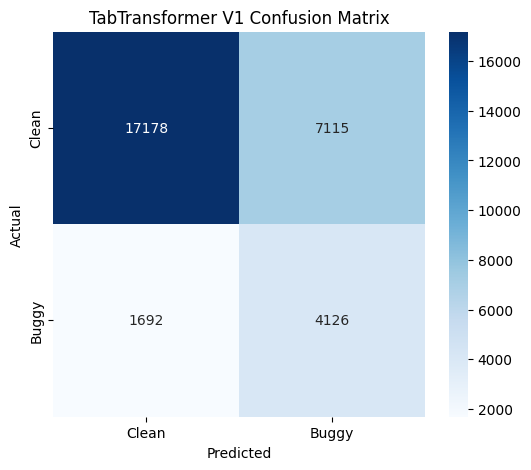

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_v1 = confusion_matrix(
    all_labels_v1,
    all_predictions_v1
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_v1,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Clean", "Buggy"],
    yticklabels=["Clean", "Buggy"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("TabTransformer V1 Confusion Matrix")

plt.show()

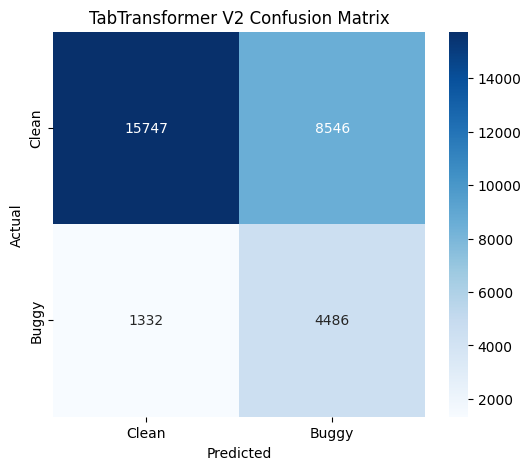

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_v2 = confusion_matrix(
    all_labels_v2,
    all_predictions_v2
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_v2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Clean", "Buggy"],
    yticklabels=["Clean", "Buggy"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("TabTransformer V2 Confusion Matrix")

plt.show()

In [33]:

import json
import torch

# Save V1 model
torch.save(
    model_v1.state_dict(),
    "/content/DL-Assignment/tabtransformer_v1_weights.pt"
)

# Save V1 metrics
tabtransformer_v1_metrics = {
    "accuracy": float(accuracy_v1),
    "precision": float(precision_v1),
    "recall": float(recall_v1),
    "f1": float(f1_v1),
    "roc_auc": float(roc_auc_v1),
    "pr_auc": float(pr_auc_v1)
}

with open(
    "/content/DL-Assignment/tabtransformer_v1_metrics.json",
    "w"
) as f:
    json.dump(
        tabtransformer_v1_metrics,
        f,
        indent=2
    )

# Save V1 training history
tabtransformer_v1_history = {
    "train_loss": train_losses_v1,
    "val_loss": val_losses_v1,
    "train_accuracy": train_accuracies_v1,
    "val_accuracy": val_accuracies_v1
}

with open(
    "/content/DL-Assignment/tabtransformer_v1_history.json",
    "w"
) as f:
    json.dump(
        tabtransformer_v1_history,
        f,
        indent=2
    )

print("TabTransformer V1 model and results saved successfully!")

print("\nSaved files:")
print("tabtransformer_v1_weights.pt")
print("tabtransformer_v1_metrics.json")
print("tabtransformer_v1_history.json")

print("\n===== TabTransformer V1 Final Metrics =====")
print(f"Accuracy : {accuracy_v1:.4f}")
print(f"Precision: {precision_v1:.4f}")
print(f"Recall   : {recall_v1:.4f}")
print(f"F1 Score : {f1_v1:.4f}")
print(f"ROC-AUC  : {roc_auc_v1:.4f}")
print(f"PR-AUC   : {pr_auc_v1:.4f}")

TabTransformer V1 model and results saved successfully!

Saved files:
tabtransformer_v1_weights.pt
tabtransformer_v1_metrics.json
tabtransformer_v1_history.json

===== TabTransformer V1 Final Metrics =====
Accuracy : 0.7075
Precision: 0.3670
Recall   : 0.7092
F1 Score : 0.4837
ROC-AUC  : 0.7813
PR-AUC   : 0.4782


In [32]:
# ==========================================
# Save TabTransformer V2 Results
# ==========================================

import json
import torch

# Save V2 model
V2_MODEL_PATH = "/content/DL-Assignment/tabtransformer_v2_weights.pt"

torch.save(
    model_v2.state_dict(),
    V2_MODEL_PATH
)


# Save V2 metrics
tabtransformer_v2_metrics = {
    "accuracy": float(accuracy_v2),
    "precision": float(precision_v2),
    "recall": float(recall_v2),
    "f1": float(f1_v2),
    "roc_auc": float(roc_auc_v2),
    "pr_auc": float(pr_auc_v2)
}

V2_METRICS_PATH = "/content/DL-Assignment/tabtransformer_v2_metrics.json"

with open(V2_METRICS_PATH, "w") as f:
    json.dump(
        tabtransformer_v2_metrics,
        f,
        indent=2
    )


# Save V2 training history
tabtransformer_v2_history = {
    "train_loss": train_losses_v2,
    "val_loss": val_losses_v2,
    "train_accuracy": train_accuracies_v2,
    "val_accuracy": val_accuracies_v2
}

V2_HISTORY_PATH = "/content/DL-Assignment/tabtransformer_v2_history.json"

with open(V2_HISTORY_PATH, "w") as f:
    json.dump(
        tabtransformer_v2_history,
        f,
        indent=2
    )


print("TabTransformer V2 model and results saved successfully!")

print("\nSaved files:")
print(V2_MODEL_PATH)
print(V2_METRICS_PATH)
print(V2_HISTORY_PATH)

print("\n===== TabTransformer V2 Final Metrics =====")
print(f"Accuracy : {accuracy_v2:.4f}")
print(f"Precision: {precision_v2:.4f}")
print(f"Recall   : {recall_v2:.4f}")
print(f"F1 Score : {f1_v2:.4f}")
print(f"ROC-AUC  : {roc_auc_v2:.4f}")
print(f"PR-AUC   : {pr_auc_v2:.4f}")

TabTransformer V2 model and results saved successfully!

Saved files:
/content/DL-Assignment/tabtransformer_v2_weights.pt
/content/DL-Assignment/tabtransformer_v2_metrics.json
/content/DL-Assignment/tabtransformer_v2_history.json

===== TabTransformer V2 Final Metrics =====
Accuracy : 0.6719
Precision: 0.3442
Recall   : 0.7711
F1 Score : 0.4760
ROC-AUC  : 0.7833
PR-AUC   : 0.4705
